In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Understand the Data
df = pd.read_csv('house_prices.csv')

print("Data Head:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())


Data Head:
   Property_ID  Area  Bedrooms  Bathrooms  Age     Location Property_Type  \
0    PROP0001  3712         4          3   36        Rural         House   
1    PROP0002  1591         4          1   35       Suburb         House   
2    PROP0003  1646         4          3   20        Rural         Villa   
3    PROP0004  4814         1          2   13  City Center         Villa   
4    PROP0005   800         4          2   38       Suburb     Apartment   

      Price  
0  22260000  
1  16057500  
2  12730000  
3  50840000  
4  10650000  

Missing values:
 Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


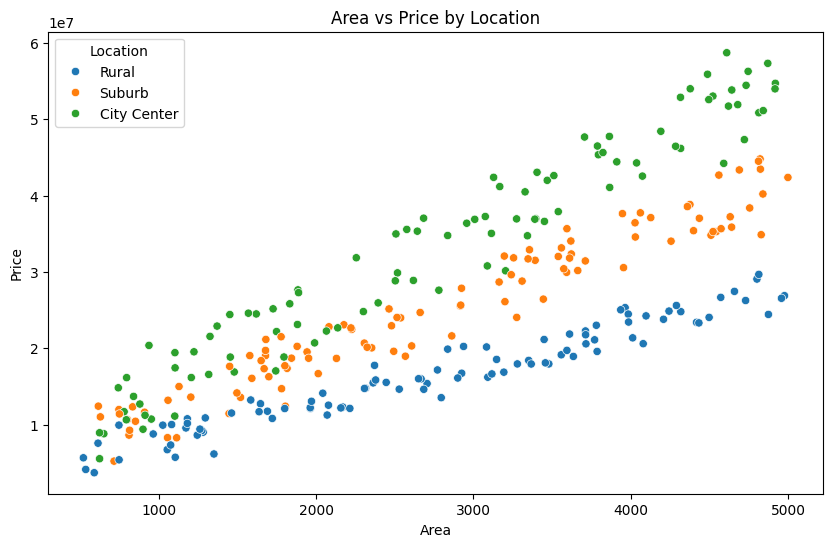

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area', y='Price', hue='Location')
plt.title('Area vs Price by Location')
plt.savefig('area_vs_price.png') # Saving for GitHub doc
plt.show()

In [24]:
df_encoded = pd.get_dummies(df, columns=['Location', 'Property_Type'], drop_first=True)
df_encoded = df_encoded.drop('Property_ID', axis=1) # Dropping irrelevant variables

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
print("\n Linear Regression from Scratch")
# Simple math logic for linear distribution (Area -> Price)
def simple_regression(x, y):
    n = len(x)
    m = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / (n * np.sum(x**2) - np.sum(x)**2)
    b = (np.sum(y) - m * np.sum(x)) / n
    return m, b

m, b = simple_regression(X_train['Area'].values, y_train.values)
print(f"Intercept: {b:.2f}, Coefficient: {m:.2f}")



 Linear Regression from Scratch
Intercept: 3162013.16, Coefficient: 7889.31


In [26]:
print("\nScikit-learn Linear Regression")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict Output
y_pred_lr = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE: ${mae:,.2f}")
print(f"R² Score: {r2:.4f}")


Scikit-learn Linear Regression
MAE: $2,188,736.34
R² Score: 0.9406


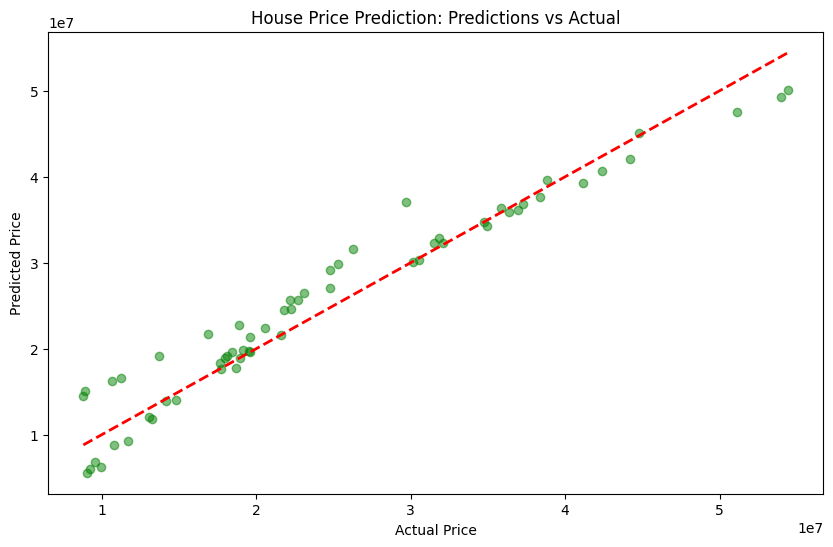

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('House Price Prediction: Predictions vs Actual')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.savefig('predictions_vs_actual.png') # Saving for GitHub doc
plt.show()

In [28]:
print("\nRandom Forest Regressor Insights")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Improved MAE: ${mae_rf:,.2f}")
print(f"Improved R² Score: {r2_rf:.4f}")


Random Forest Regressor Insights
Improved MAE: $1,493,949.17
Improved R² Score: 0.9711


In [21]:
# Extract features
feature_importance = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nBest Features:")
print(feature_importance)


Best Features:
               Feature  Importance
0                 Area    0.693187
4       Location_Rural    0.201724
5      Location_Suburb    0.073616
1             Bedrooms    0.019140
3                  Age    0.008199
2            Bathrooms    0.002207
7  Property_Type_Villa    0.001143
6  Property_Type_House    0.000783
